# Tahap 6 — Evaluasi & Interpretasi
### Proyek: Prediksi Customer Churn pada Perusahaan Telekomunikasi

Lanjutan dari `05_modeling.ipynb`. Semua 6 model yang sudah dilatih & lolos
cross-validation sekarang dievaluasi di **`X_test`/`y_test`** — data yang
sejak Tahap 4 belum pernah disentuh oleh proses training, CV, atau SMOTE
manapun, sehingga hasilnya representasi paling jujur soal performa model
di dunia nyata.

Isi notebook:

1. Tabel perbandingan metrik (precision, recall, F1, ROC-AUC) di test set.
2. ROC curve semua model.
3. Confusion matrix & classification report model terbaik.
4. Feature importance — menjawab **Pertanyaan Bisnis #1**: faktor apa yang
   paling berhubungan dengan churn?

## 1. Setup & Load Model + Test Set

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, accuracy_score,
    roc_curve, confusion_matrix, classification_report,
)

DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
FIG_DIR = "../reports/figures"
REPORTS_DIR = "../reports"

X_test = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns")

model_names = [
    "logreg_class_weight", "logreg_smote",
    "rf_class_weight", "rf_smote",
    "xgb_class_weight", "xgb_smote",
]
models = {name: joblib.load(f"{MODELS_DIR}/{name}.joblib") for name in model_names}

print(f"X_test: {X_test.shape}   Churn rate y_test: {y_test.mean():.4f}")
print(f"Model dimuat: {list(models.keys())}")

X_test: (1409, 33)   Churn rate y_test: 0.2654
Model dimuat: ['logreg_class_weight', 'logreg_smote', 'rf_class_weight', 'rf_smote', 'xgb_class_weight', 'xgb_smote']


In [2]:
# Palet warna konsisten dengan notebook 03_eda.ipynb (skill dataviz)
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

BLUE = "#2a78d6"     # slot 1 -> algoritma Logistic Regression / "menahan churn"
ORANGE = "#eb6834"   # slot 2 -> algoritma Random Forest / "mendorong churn"
AQUA = "#1baf7a"      # slot 3 -> algoritma XGBoost

ALGO_COLORS = {"logreg": BLUE, "rf": ORANGE, "xgb": AQUA}
CHURN_COLORS = {"No": BLUE, "Yes": ORANGE}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRIDLINE,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Tabel Metrik di Test Set

Dihitung untuk kelas `Churn = 1` (bukan rata-rata dua kelas), sesuai
prioritas bisnis di brief: recall dulu, lalu precision, F1 sebagai
keseimbangan, ROC-AUC sebagai ukuran kemampuan membedakan di semua
threshold. `accuracy` tetap dihitung tapi **hanya sebagai pembanding** —
bukan patokan keputusan, karena datanya imbalance (~73/27).

In [3]:
rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "accuracy": accuracy_score(y_test, y_pred),
    })

test_metrics = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
test_metrics = test_metrics.round(4)
test_metrics.to_csv(f"{REPORTS_DIR}/test_metrics_comparison.csv", index=False)

test_metrics

,model,roc_auc,f1,precision,recall,accuracy
0,logreg_class_weight,0.8415,0.6162,0.5034,0.7941,0.7374
1,logreg_smote,0.8397,0.6112,0.5000,0.7861,0.7346
2,rf_class_weight,0.8286,0.5953,0.5571,0.6390,0.7693
3,rf_smote,0.8268,0.5870,0.5707,0.6043,0.7743
4,xgb_class_weight,0.8150,0.5810,0.5594,0.6043,0.7686
5,xgb_smote,0.8130,0.5722,0.5619,0.5829,0.7686


**Model terbaik di test set: `logreg_class_weight`** (Logistic Regression
dengan `class_weight="balanced"`) — konsisten dengan hasil cross-validation
di Tahap 5, jadi bukan kebetulan/overfit ke satu split tertentu. ROC-AUC
dan F1-nya juga melewati target brief (ROC-AUC > 0.80, F1 churn > 0.55).

Sisa notebook ini fokus ke model terbaik ini untuk confusion matrix &
classification report, tapi feature importance tetap dibandingkan dengan
Random Forest juga (bagian 5) untuk cross-check dari sudut pandang model
yang berbeda.

## 3. ROC Curve — Semua Model

Warna mengikuti **algoritma** (biru=Logistic Regression, oranye=Random
Forest, aqua=XGBoost — 3 slot pertama palet kategorikal, aman dipakai
berdampingan). Strategi imbalance dibedakan lewat **garis solid vs putus-putus**
(class_weight vs SMOTE) — encoding sekunder ini dipakai karena membandingkan
6 garis sekaligus dengan warna saja akan sulit dibedakan mata.

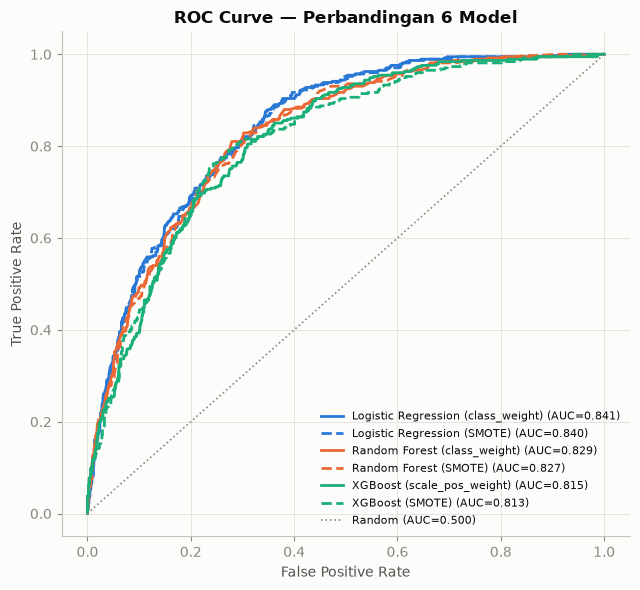

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 6))

style_map = {
    "logreg_class_weight": (ALGO_COLORS["logreg"], "-", "Logistic Regression (class_weight)"),
    "logreg_smote": (ALGO_COLORS["logreg"], "--", "Logistic Regression (SMOTE)"),
    "rf_class_weight": (ALGO_COLORS["rf"], "-", "Random Forest (class_weight)"),
    "rf_smote": (ALGO_COLORS["rf"], "--", "Random Forest (SMOTE)"),
    "xgb_class_weight": (ALGO_COLORS["xgb"], "-", "XGBoost (scale_pos_weight)"),
    "xgb_smote": (ALGO_COLORS["xgb"], "--", "XGBoost (SMOTE)"),
}

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    color, linestyle, label = style_map[name]
    ax.plot(fpr, tpr, color=color, linestyle=linestyle, linewidth=2,
            label=f"{label} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], color=INK_MUTED, linestyle=":", linewidth=1.2, label="Random (AUC=0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Perbandingan 6 Model", color=INK_PRIMARY, fontweight="bold")
ax.legend(loc="lower right", fontsize=8, frameon=False)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_roc_curve_comparison.png", dpi=150, facecolor=SURFACE)
plt.show()

## 4. Confusion Matrix & Classification Report — Model Terbaik

Threshold default `0.5` dipakai di sini (optimasi threshold berdasarkan
biaya kampanye vs revenue yang diselamatkan adalah ide pengembangan lanjut
di brief bagian 7, di luar scope Tahap 6).

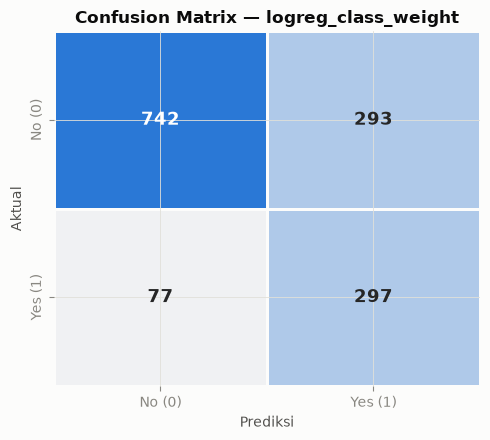

              precision    recall  f1-score   support

      No (0)       0.91      0.72      0.80      1035
     Yes (1)       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [5]:
best_model_name = test_metrics.iloc[0]["model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
cm_labels = ["No (0)", "Yes (1)"]

blue_seq_cmap = sns.light_palette(BLUE, as_cmap=True)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap=blue_seq_cmap,
    xticklabels=cm_labels, yticklabels=cm_labels,
    linewidths=1, linecolor=SURFACE, cbar=False,
    annot_kws={"fontsize": 13, "fontweight": "bold"}, ax=ax,
)
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
ax.set_title(f"Confusion Matrix — {best_model_name}", color=INK_PRIMARY, fontweight="bold")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_confusion_matrix_best_model.png", dpi=150, facecolor=SURFACE)
plt.show()

print(classification_report(y_test, y_pred_best, target_names=cm_labels))

**Cara baca confusion matrix ini untuk tim bisnis:**

- **Kanan-bawah (True Positive)**: pelanggan yang benar-benar churn dan
  berhasil ditangkap model → bisa dihubungi tim retensi lebih dulu.
- **Kiri-bawah (False Negative)**: pelanggan yang churn tapi **tidak**
  tertangkap model → ini yang paling mahal secara bisnis (hilang tanpa
  sempat ditawari retensi).
- **Kanan-atas (False Positive)**: pelanggan yang sebenarnya tidak churn
  tapi ditandai berisiko → biaya kampanye retensi "terbuang", tapi jauh
  lebih murah daripada kehilangan pelanggan (False Negative).

## 5. Feature Importance — Menjawab Pertanyaan Bisnis #1

### 5.1 Koefisien Logistic Regression (model terbaik)

Karena fitur numerik sudah di-scale (`StandardScaler`) sebelum masuk
model, besar-kecilnya koefisien **bisa dibandingkan langsung antar
fitur** — bukan hanya tanda positif/negatifnya. Warna dipakai konsisten
dengan seluruh notebook proyek ini: **oranye = mendorong churn** (koefisien
positif), **biru = menahan churn** (koefisien negatif).

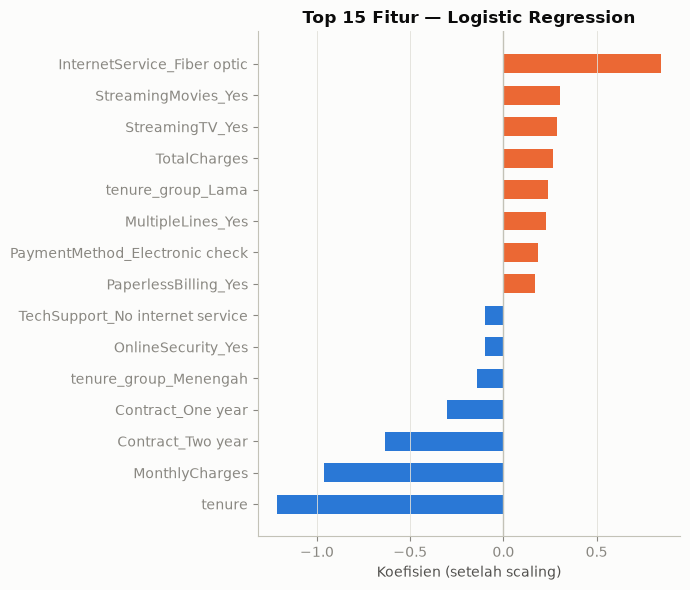

InternetService_Fiber optic        0.844267
StreamingMovies_Yes                0.303597
StreamingTV_Yes                    0.289414
TotalCharges                       0.267165
tenure_group_Lama                  0.238561
MultipleLines_Yes                  0.227770
PaymentMethod_Electronic check     0.188014
PaperlessBilling_Yes               0.169178
TechSupport_No internet service   -0.099653
OnlineSecurity_Yes                -0.100710
tenure_group_Menengah             -0.143926
Contract_One year                 -0.303447
Contract_Two year                 -0.635620
MonthlyCharges                    -0.960362
tenure                            -1.214340
dtype: float64

In [6]:
def get_classifier(model):
    return model.named_steps["clf"] if hasattr(model, "named_steps") else model


logreg_clf = get_classifier(best_model)
coefs = pd.Series(logreg_clf.coef_[0], index=X_test.columns)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)
top_coefs = top_coefs.sort_values()

colors = [ORANGE if v > 0 else BLUE for v in top_coefs.values]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_coefs.index, top_coefs.values, color=colors, height=0.6)
ax.axvline(0, color=BASELINE, linewidth=1)
ax.set_xlabel("Koefisien (setelah scaling)")
ax.set_title("Top 15 Fitur — Logistic Regression", color=INK_PRIMARY, fontweight="bold")
ax.grid(axis="y", visible=False)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_logreg_coefficients.png", dpi=150, facecolor=SURFACE)
plt.show()

top_coefs.sort_values(ascending=False)

### 5.2 Feature Importance Random Forest (cross-check)

Random Forest mengukur pentingnya fitur lewat kontribusinya mengurangi
impuritas di seluruh pohon — cara pandang berbeda dari koefisien linear,
berguna untuk cross-check apakah kedua model "setuju" soal faktor yang
paling penting.

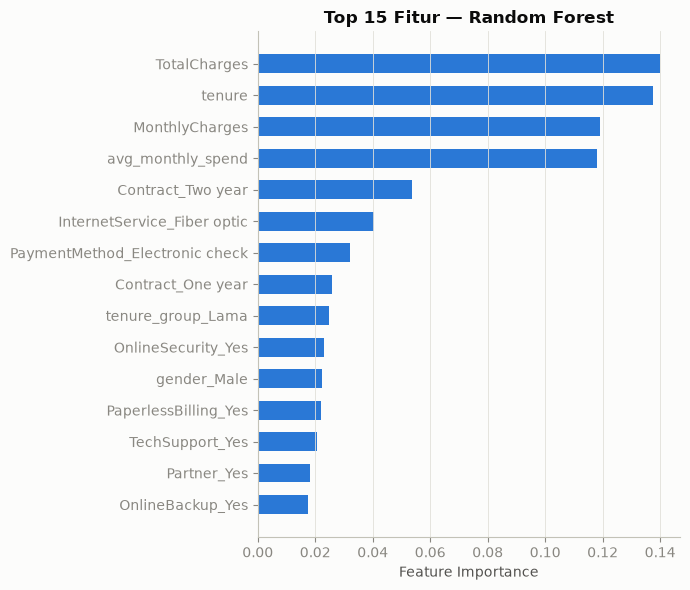

TotalCharges                      0.139908
tenure                            0.137555
MonthlyCharges                    0.118917
avg_monthly_spend                 0.117862
Contract_Two year                 0.053726
InternetService_Fiber optic       0.040486
PaymentMethod_Electronic check    0.031953
Contract_One year                 0.025687
tenure_group_Lama                 0.024693
OnlineSecurity_Yes                0.022951
gender_Male                       0.022422
PaperlessBilling_Yes              0.022111
TechSupport_Yes                   0.020476
Partner_Yes                       0.018201
OnlineBackup_Yes                  0.017636
dtype: float64

In [7]:
rf_clf = get_classifier(models["rf_class_weight"])
rf_importance = pd.Series(rf_clf.feature_importances_, index=X_test.columns)
top_rf = rf_importance.sort_values(ascending=False).head(15).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_rf.index, top_rf.values, color=BLUE, height=0.6)
ax.set_xlabel("Feature Importance")
ax.set_title("Top 15 Fitur — Random Forest", color=INK_PRIMARY, fontweight="bold")
ax.grid(axis="y", visible=False)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_rf_feature_importance.png", dpi=150, facecolor=SURFACE)
plt.show()

top_rf.sort_values(ascending=False)

## 6. Ringkasan Tahap 6

**Model terbaik: Logistic Regression (`class_weight="balanced"`)**
— dipilih konsisten baik dari cross-validation (Tahap 5) maupun test set
(tahap ini), tanda hasilnya bukan kebetulan satu split data.

**Menjawab Pertanyaan Bisnis #1** — faktor yang paling berhubungan dengan
churn. Dua model (koefisien Logistic Regression & feature importance
Random Forest) sepakat soal **kelompok fitur** yang paling berpengaruh:
`tenure`/`TotalCharges`/`MonthlyCharges`, jenis `Contract`, `InternetService`,
dan `PaymentMethod`. Rinciannya:

- **Paling kuat mendorong churn:** `InternetService = Fiber optic`
  (koefisien terbesar kedua setelah `tenure`), diikuti berlangganan
  `StreamingMovies`/`StreamingTV`, `PaymentMethod = Electronic check`.
- **Paling kuat menahan churn:** `tenure` tinggi (koefisien negatif
  terbesar), kontrak `Two year`, lalu `Contract = One year`, dan
  berlangganan `OnlineSecurity`.

**Catatan penting soal interpretasi (kejujuran teknis):** dua fitur —
`tenure_group_Lama` dan `MonthlyCharges` — punya tanda koefisien yang
**berlawanan** dengan pola sederhana yang terlihat di EDA (Tahap 3), yaitu
korelasi *positif* meski secara univariat kelompok tenure lama churn-nya
rendah, dan koefisien *negatif* untuk `MonthlyCharges` meski median
tagihan pelanggan churn lebih tinggi. Ini bukan kontradiksi data, melainkan
efek **multikolinearitas**: `tenure_group` diturunkan langsung dari
`tenure` (yang sudah punya koefisien dominan di model), dan
`MonthlyCharges` sangat berkorelasi dengan `InternetService_Fiber optic`
(pelanggan fiber otomatis bayar lebih mahal) — begitu `InternetService`
sudah "menyerap" sebagian sinyal itu di model, sisa pengaruh `MonthlyCharges`
murni (dengan jenis internet yang sama) jadi berlawanan arah dari pola
univariat-nya.

**Implikasinya untuk komunikasi ke tim bisnis:** pesan yang aman dan
konsisten di semua sudut pandang (EDA, korelasi, churn rate per grup,
feature importance dua model) adalah pada level fitur **mentah/univariat**
— kontrak bulanan, tenure rendah, dan layanan fiber optic — bukan pada
detail arah koefisien dari fitur turunan yang saling berkorelasi tinggi.
Detail teknis ini didokumentasikan di sini justru supaya Tahap 7
(komunikasi hasil) tidak salah mengutip arah pengaruh yang sebenarnya
tidak stabil secara statistik.

**File yang dihasilkan:**
- `reports/test_metrics_comparison.csv` — tabel metrik 6 model di test set.
- `reports/figures/07_roc_curve_comparison.png`
- `reports/figures/08_confusion_matrix_best_model.png`
- `reports/figures/09_logreg_coefficients.png`
- `reports/figures/10_rf_feature_importance.png`

**Lanjut ke Tahap 7 — Komunikasi Hasil:**

Meringkas semua temuan di atas jadi 3–5 insight utama + rekomendasi aksi
konkret untuk tim retensi, ditulis dalam bahasa non-teknis (executive
summary).